In [1]:
#%matplotlib qt5

In [2]:
import time
import numpy as np
import pykep as pk
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from pyorb.kepler import mean_to_eccentric

import sys
sys.path.append("../src")
from utils import *
from cartesian_dynamics import *
from ks_dynamics import *
from ks_transform import *

In [3]:
GM_EARTH = 3.986e5 # km^3/s^2

# Define orbits
orbits = { # [a, e, i, RAAN, omega, E]
    'A': {'a': 7000, 'e': 0.1, 'i': 0.0, 'RAAN': 0.0, 'omega': 0.0, 'M': 0.0},       
    'B': {'a': 6378 + 750, 'e': 0.9, 'i': 0.0, 'RAAN': 0.0, 'omega': 0.0, 'M': 0.0}, 
    'C': {'a': 7000, 'e': 2.0, 'i': 0.0, 'RAAN': 0.0, 'omega': 0.0, 'M': 0.0}, 
}

# Define simulation parameters
class SIM_PARAMS:
    # Number of orbits to simulate
    num_orbits = 3

    # Sampling time (time step) in seconds
    sampling_time = 30.0  # seconds

    # Integrator to use
    method = 'RK45'

    # Integrator tolerances
    atol = 1e-12    # Absolute tolerance
    rtol = 1e-13    # Relative tolerance

In [4]:
orbit_to_use = 'B'
a, e, i, RAAN, omega, M = orbits[orbit_to_use]['a'], orbits[orbit_to_use]['e'], orbits[orbit_to_use]['i'], orbits[orbit_to_use]['RAAN'], orbits[orbit_to_use]['omega'], orbits[orbit_to_use]['M']

# === INITIAL CONDITIONS ===
# At periapsis: E = 0 (M = 0)
oe_vec_0 = [np.abs(a) if a < 0 else a, e, i, RAAN, omega, M]
r_vec_0, v_vec_0 = pk.par2ic(oe_vec_0, GM_EARTH)
r_vec_0 = np.array(r_vec_0)
v_vec_0 = np.array(v_vec_0)

# Initial state in Cartesian and KS coordinates
x_vec_0 = np.concatenate([r_vec_0, v_vec_0])
ks_state_0 = state_cartesian_to_ks(x_vec_0)
h_0 = energy_ks(ks_state_0[:4], ks_state_0[4:8], GM_EARTH)
ks_state_augmented_0 = np.concatenate([ks_state_0, np.array([h_0])])

# === TIME SETTINGS ===
dt = SIM_PARAMS.sampling_time
n_orbits = SIM_PARAMS.num_orbits
T_orbital = 2 * np.pi * np.sqrt(np.abs(a) ** 3 / GM_EARTH)  # orbital period [s]
t_final = n_orbits * T_orbital
N = int(t_final / dt)
print(f"Orbital period: {T_orbital/3600:.2f} hours | Total simulation time: {t_final/3600:.2f} hours | Number of time steps: {N}")

Orbital period: 1.66 hours | Total simulation time: 4.99 hours | Number of time steps: 598


In [5]:
# Cartesian solutions (3D)
t_vals = np.linspace(0, N * dt, N + 1)

# Numerical solution
start_time_cartesian = time.time()
x_traj_cartesian, t_traj_cartesian = propagate_cartesian_keplerian_dynamics(x_vec_0, t_vals, SIM_PARAMS, GM_EARTH)
elapsed_time_cartesian = time.time() - start_time_cartesian
x_cartesian, y_cartesian, z_cartesian, theta_cartesian, r_vec_cartesian, r_vec_norm_cartesian = r_vecs2several_quantities(x_traj_cartesian[:, :3])

# Analytical solution
x_traj_analytical = propagate_analytical_keplerian_dynamics(oe_vec_0, t_vals, GM_EARTH)
x_cartesian_analytical, y_cartesian_analytical, z_cartesian_analytical, theta_cartesian_analytical, r_vec_cartesian_analytical, r_vec_norm_cartesian_analytical = r_vecs2several_quantities(x_traj_analytical[:, :3])

In [6]:
ds = dt / a
s_vals = np.linspace(0, N * ds, N + 1)

# Numerical soltution
start_time_ks = time.time()
solution_ks = solve_ivp(lambda s, ks_state_augmented: ks_gravity(ks_state_augmented, s, GM_EARTH), [s_vals[0], s_vals[-1]], ks_state_augmented_0, method=SIM_PARAMS.method, t_eval=s_vals, rtol=SIM_PARAMS.rtol, atol=SIM_PARAMS.atol)
ks_augmented_states_ks = solution_ks.y.T
elapsed_time_ks = time.time() - start_time_ks
x_traj_ks = np.array([position_ks_to_cartesian(ks_augmented_states_ks[i, :4]) for i in range(N + 1)])
x_ks, y_ks, z_ks, theta_ks, r_vec_ks, r_vec_norm_ks = r_vecs2several_quantities(x_traj_ks[:, :3])

# Analytical solution
t_vals_ks = np.zeros_like(s_vals)
for i in range(N + 1):
    if i > 0:
        t_vals_ks[i] = t_vals_ks[i - 1] + (r_vec_norm_ks[i] + r_vec_norm_ks[i - 1]) / 2 * ds
x_traj_analytical_ks = propagate_analytical_keplerian_dynamics(oe_vec_0, t_vals_ks, GM_EARTH)
x_ks_analytical, y_ks_analytical, z_ks_analytical, theta_ks_analytical, r_vec_ks_analytical, r_vec_norm_ks_analytical = r_vecs2several_quantities(x_traj_analytical_ks[:, :3])

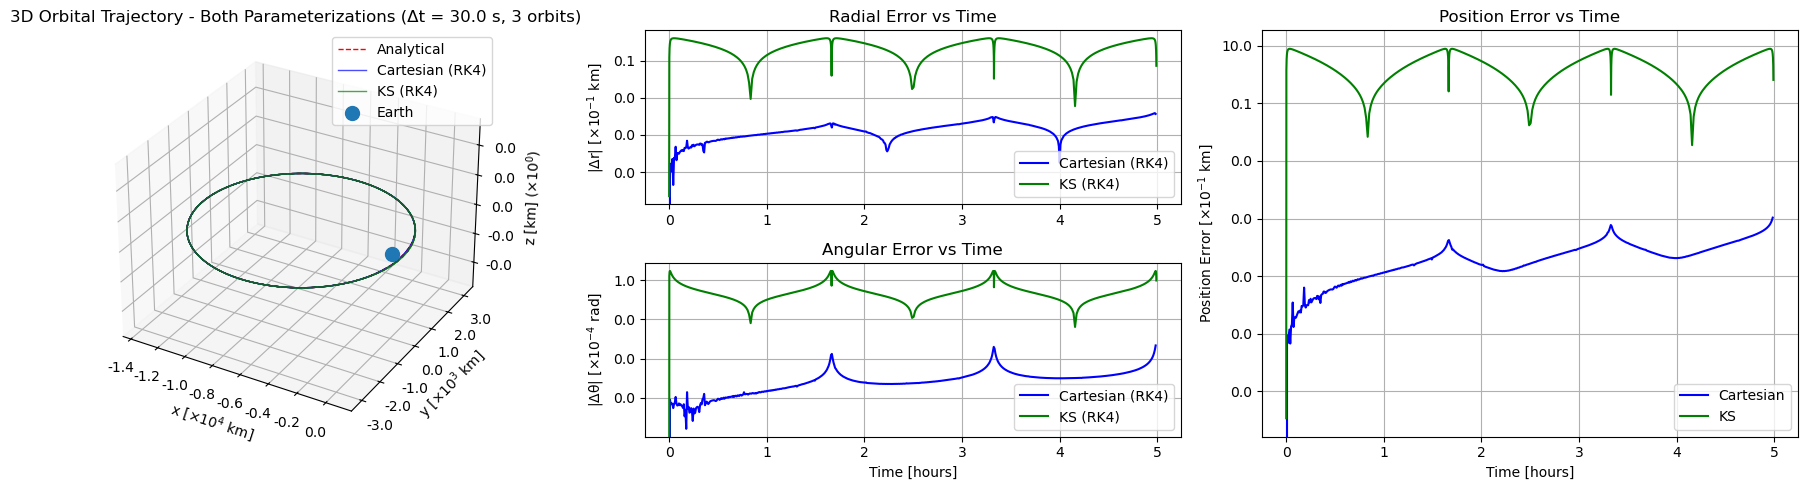

In [11]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(2, 3)  # 2 rows, 3 columns total

radial_error_cartesian = r_vec_norm_cartesian - r_vec_norm_cartesian_analytical
radial_error_ks = r_vec_norm_ks - r_vec_norm_ks_analytical
angular_error_cartesian = np.mod(theta_cartesian - theta_cartesian_analytical + np.pi, 2 * np.pi) - np.pi
angular_error_ks = np.mod(theta_ks - theta_ks_analytical + np.pi, 2 * np.pi) - np.pi
position_error_cartesian = np.linalg.norm(r_vec_cartesian - r_vec_cartesian_analytical, axis=1)
position_error_ks = np.linalg.norm(r_vec_ks - r_vec_ks_analytical, axis=1)

# --- Plot 1: 3D Trajectory comparison (spans both rows in column 0) - Both parameterizations
ax1 = fig.add_subplot(gs[:, 0], projection='3d')
ax1.plot(x_cartesian_analytical, y_cartesian_analytical, z_cartesian_analytical, 
         '--', label='Analytical', color='red', linewidth=1)
ax1.plot(x_cartesian, y_cartesian, z_cartesian, 
         label='Cartesian (RK4)', color='blue', linewidth=1, alpha=0.7)
ax1.plot(x_ks, y_ks, z_ks, 
         label='KS (RK4)', color='green', linewidth=1, alpha=0.7)
ax1.scatter(0, 0, 0, 'ro', label='Earth', s=100)
ax1.set_xlabel('x [km]')
ax1.set_ylabel('y [km]')
ax1.set_zlabel('z [km]')
ax1.set_title(f'3D Orbital Trajectory - Both Parameterizations (Δt = {dt} s, {n_orbits} orbits)')
ax1.legend()

# --- Plot 2a: Δr vs Time (top-right) - Both parameterizations
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(t_vals / 3600, np.abs(radial_error_cartesian), label='Cartesian (RK4)', color='blue', linewidth=1.5)
ax2.semilogy(t_vals_ks / 3600, np.abs(radial_error_ks), label='KS (RK4)', color='green', linewidth=1.5)
ax2.set_ylabel('|Δr| [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend()
ax2.grid(True)

# --- Plot 2b: Δθ vs Time (bottom-right) - Both parameterizations
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(t_vals / 3600, np.abs(angular_error_cartesian), label='Cartesian (RK4)', color='blue', linewidth=1.5)
ax3.semilogy(t_vals_ks / 3600, np.abs(angular_error_ks), label='KS (RK4)', color='green', linewidth=1.5)
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('|Δθ| [rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend()
ax3.grid(True)

# --- Plot 3: Position error vs Time (spans both rows in column 2) - Both parameterizations
ax4 = fig.add_subplot(gs[:, 2])
ax4.semilogy(t_vals / 3600, position_error_cartesian, label='Cartesian', color='blue', linewidth=1.5)
ax4.semilogy(t_vals_ks / 3600, position_error_ks, label='KS', color='green', linewidth=1.5)
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend()
ax4.grid(True)

# Apply scientific tick formatting
apply_scientific_tick_labels(ax1, 'x', [x_cartesian_analytical, x_cartesian, x_ks])
apply_scientific_tick_labels(ax1, 'y', [y_cartesian_analytical, y_cartesian, y_ks])
apply_scientific_tick_labels(ax1, 'z', [z_cartesian_analytical, z_cartesian, z_ks])
apply_scientific_tick_labels(ax2, 'y', [radial_error_cartesian, radial_error_ks])
apply_scientific_tick_labels(ax3, 'y', [angular_error_cartesian, angular_error_ks])
apply_scientific_tick_labels(ax4, 'y', [position_error_cartesian, position_error_ks])

# --- Final layout
plt.tight_layout()
plt.show()

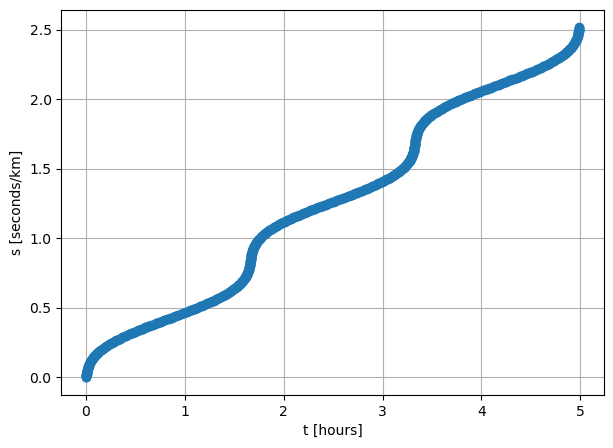

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(t_vals_ks / 3600, s_vals, marker='o', linestyle='-')
plt.xlabel('t [hours]')
plt.ylabel('s [seconds/km]')
plt.grid(True)
plt.show()